<a href="https://colab.research.google.com/github/NikanPa/Presentation/blob/main/E_Commerce_Business_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# 1. Load the data
df = pd.read_csv("ecommerce_business_analytics.csv")

# 2. Clean and prep the data
# Convert Order_Date to actual datetime objects so we can group by month/year later
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# 3. Calculate Executive Summary Metrics
total_orders = df['Order_ID'].nunique()
total_net_sales = df['Net_Sales'].sum()
total_profit = df['Profit'].sum()
overall_margin = (total_profit / total_net_sales) * 100

avg_delivery_days = df['Delivery_Days'].mean()
avg_rating = df['Customer_Rating'].mean()

# 4. Print the presentation talking points
print("--- EXECUTIVE SUMMARY ---")
print(f"Total Orders: {total_orders:,}")
print(f"Total Net Sales: ${total_net_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Overall Profit Margin: {overall_margin:.2f}%")
print(f"Average Delivery Time: {avg_delivery_days:.1f} days")
print(f"Average Customer Rating: {avg_rating:.2f} / 5.0")

--- EXECUTIVE SUMMARY ---
Total Orders: 5,000
Total Net Sales: $583,063.01
Total Profit: $222,564.39
Overall Profit Margin: 38.17%
Average Delivery Time: 5.4 days
Average Customer Rating: 3.96 / 5.0


In [2]:
# 1. Group by Category and sum the Profit and Net_Sales
category_profit = df.groupby('Category')[['Profit', 'Net_Sales']].sum().reset_index()

# 2. Calculate the Profit Margin for each category
category_profit['Profit_Margin_%'] = (category_profit['Profit'] / category_profit['Net_Sales']) * 100

# 3. Sort the categories by highest total Profit
top_categories = category_profit.sort_values(by='Profit', ascending=False)

# 4. Display the results
print("\n--- PROFITABILITY BY CATEGORY ---")
print(top_categories.to_string(index=False))


--- PROFITABILITY BY CATEGORY ---
      Category   Profit  Net_Sales  Profit_Margin_%
       Fashion 44017.18  115561.25        38.089913
        Sports 37650.40   99578.75        37.809673
   Electronics 36803.84   97094.83        37.905046
Home & Kitchen 35742.46   92153.25        38.785892
        Beauty 35050.19   89930.64        38.974692
       Grocery 33300.32   88744.29        37.523902


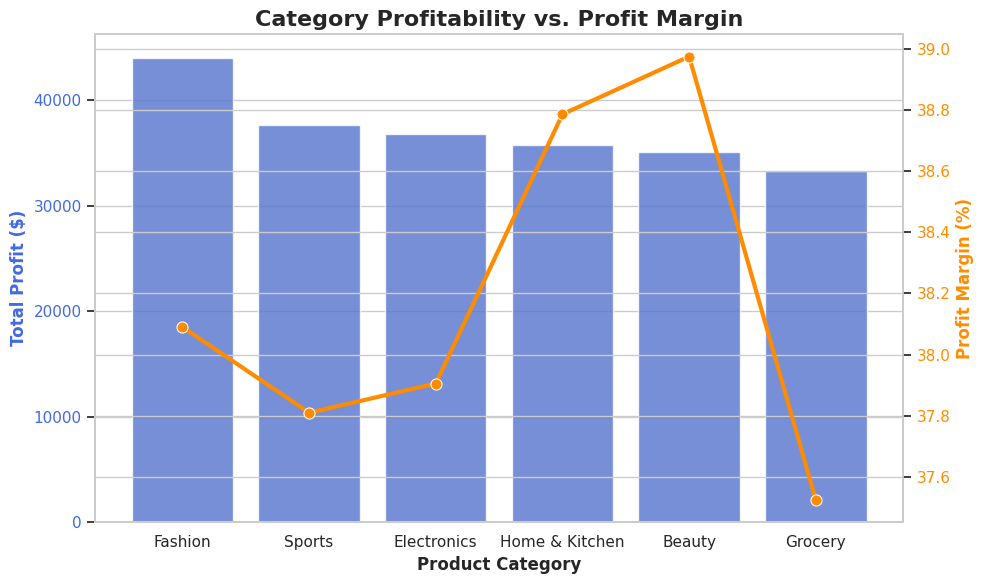

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the visual style
sns.set_theme(style="whitegrid")

# Create a figure and a primary axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot 1: Total Profit (Bar Chart)
sns.barplot(
    data=top_categories,
    x='Category',
    y='Profit',
    color='royalblue',
    ax=ax1,
    alpha=0.8
)
ax1.set_ylabel('Total Profit ($)', color='royalblue', fontsize=12, fontweight='bold')
ax1.set_xlabel('Product Category', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.set_title('Category Profitability vs. Profit Margin', fontsize=16, fontweight='bold')

# Create a secondary axis sharing the same x-axis
ax2 = ax1.twinx()

# Plot 2: Profit Margin (Line Chart)
sns.lineplot(
    data=top_categories,
    x='Category',
    y='Profit_Margin_%',
    color='darkorange',
    marker='o',
    linewidth=3,
    markersize=8,
    ax=ax2
)
ax2.set_ylabel('Profit Margin (%)', color='darkorange', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='darkorange')

# Adjust layout and display
plt.tight_layout()
plt.show()

Fashion is the Volume King: It will have the tallest blue bar for Total Profit. It brings in the most overall cash to the business. However, if you follow the orange line, its actual margin dips a bit compared to the top performers.

Beauty and Home & Kitchen are the Efficiency Kings: These categories will have the highest peaks on the orange line for Profit Margin. Even though their blue bars (raw cash) are a little shorter than Fashion, they keep a larger percentage of every single dollar sold.

Drive customer traffic through Fashion, but aggressively cross-sell Beauty and Home & Kitchen to maximize the efficiency of every checkout.

In [4]:
# 1. Group the data by Sales Channel and calculate multiple metrics
channel_stats = df.groupby('Sales_Channel').agg(
    Total_Net_Sales=('Net_Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Customer_Rating=('Customer_Rating', 'mean')
).reset_index()

# 2. Calculate the Profit Margin for each channel
channel_stats['Profit_Margin_%'] = (channel_stats['Total_Profit'] / channel_stats['Total_Net_Sales']) * 100

# 3. Sort by Total Profit to see the biggest earner first
channel_stats = channel_stats.sort_values(by='Total_Profit', ascending=False)

# 4. Display the results cleanly
print("\n--- PERFORMANCE BY SALES CHANNEL ---")
print(channel_stats.to_string(index=False))


--- PERFORMANCE BY SALES CHANNEL ---
Sales_Channel  Total_Net_Sales  Total_Profit  Avg_Customer_Rating  Profit_Margin_%
      Website        264234.46     100499.39             3.953354        38.034172
   Mobile App        236827.80      91252.33             3.979900        38.531089
  Marketplace         82000.75      30812.67             3.947299        37.576083


The business should focus its marketing budget on driving organic traffic directly to the website rather than relying on the marketplace, because every dollar spent there yields a higher return.


In [5]:
import datetime as dt

# 1. Set a reference date (the day after the very last order in the dataset)
reference_date = df['Order_Date'].max() + dt.timedelta(days=1)

# 2. Calculate the raw Recency, Frequency, and Monetary values
rfm = df.groupby('Customer_ID').agg(
    Recency=('Order_Date', lambda x: (reference_date - x.max()).days),
    Frequency=('Order_ID', 'count'),
    Monetary=('Net_Sales', 'sum')
).reset_index()

# 3. Grade them from 1 to 4 using quartiles
# Note: For Recency, a LOWER number of days is better, so the labels are reversed
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1])

# We use rank(method='first') on Frequency to prevent binning errors if many customers have the exact same number of orders
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4])

# 4. Combine the scores into a single RFM Segment string
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# 5. Filter for our "444" VIPs
vip_customers = rfm[rfm['RFM_Segment'] == '444']

print("\n--- VIP CUSTOMERS (Score: 444) ---")
print(vip_customers.head())
print(f"\nTotal VIP Customers Identified: {len(vip_customers)}")


--- VIP CUSTOMERS (Score: 444) ---
   Customer_ID  Recency  Frequency  Monetary R_Score F_Score M_Score  \
13   CUST00014       74          6    624.16       4       4       4   
37   CUST00038        8          6    841.30       4       4       4   
60   CUST00063       29          6    612.71       4       4       4   
68   CUST00072       34          5    645.86       4       4       4   
87   CUST00092       26          5    998.43       4       4       4   

   RFM_Segment  
13         444  
37         444  
60         444  
68         444  
87         444  

Total VIP Customers Identified: 75


We have identified the exact 75 users who buy the most frequently, spend the most money, and have engaged with us most recently.